# Persistent Homology for Large Scale Structure

### Introduction to Persistent Homology

Persistent Homology is a method from **Topological Data Analysis (TDA)** that studies the **topological features** of point clouds across multiple scales.

Key concepts:
- **Homology**: Studies hole-like structures in data (0-dim: components/clusters, 1-dim: loops/voids, 2-dim: cavities)
- **Persistence**: Tracks how long these features exist as scale parameter changes
- **Filtration**: Parametrized family of nested complexes at increasing scales

### Why It Matters for Cosmology

The large-scale structure of the universe exhibits:
- **Clusters** of dark matter halos (filaments, clusters, nodes)
- **Voids** between these structures
- **Topological structures** encoded in cosmological parameters

Persistent homology captures these features to:
1. Constrain cosmological parameters (e.g., primordial non-Gaussianity)
2. Extract scale-dependent information
3. Avoid relying only on two-point statistics (power spectrum)

### Large Scale Structure & Cosmology

### Background

- **N-body simulations**: Evolve billions of dark matter particles from early universe to present day
- **Halo catalogs**: Extract self-bound structures (halos) representing galaxy clusters
- **Positions & Masses**: Halos have 3D spatial coordinates and mass estimates

### Box Geometry

The code operates on periodic cubic boxes:
- **Main box**: 2000 Mpc/h (comoving megaparsec/h) - full simulation volume
- **Sub-boxes**: 1000 Mpc/h - subdomain partitions for computational efficiency
- **Redshift**: Analysis at redshift z=1 (intermediate cosmic epoch)

### Halo Selection

```
Mass range: 9.189×10^12 to 10^20 Msun/h
Total halos per subbox: 252,321
Subsampling: For computational tractability
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Example 1: Create synthetic halo catalog
# Real catalog format: [Mass, X, Y, Z]

np.random.seed(42)

# Create synthetic halos
n_halos = 1000
masses = np.random.exponential(scale=1e13, size=n_halos) + 1e12  # Log-normal-like
positions = np.random.uniform(0, 2000, (n_halos, 3))  # Within 2000 Mpc/h box

catalog = np.column_stack([masses, positions])
print(f"Synthetic Catalog Shape: {catalog.shape}")
print(f"First 5 halos (Mass, X, Y, Z):\n{catalog[:5]}")
print(f"\nMass range: {catalog[:,0].min():.2e} to {catalog[:,0].max():.2e} Msun/h")
print(f"Position range: 0 to 2000 Mpc/h")

Synthetic Catalog Shape: (1000, 4)
First 5 halos (Mass, X, Y, Z):
[[5.69268090e+12 3.70265858e+02 1.08380189e+03 1.74589167e+03]
 [3.11012143e+13 1.46444977e+03 1.61312230e+03 1.31756673e+03]
 [1.41674569e+13 1.38455313e+03 1.69839130e+03 4.99336018e+02]
 [1.01294255e+13 9.78849927e+02 4.42418884e+02 1.97533602e+03]
 [2.69624870e+12 1.88811868e+03 7.88536227e+01 1.41115035e+03]]

Mass range: 1.05e+12 to 8.27e+13 Msun/h
Position range: 0 to 2000 Mpc/h


### Understanding Persistence Diagrams

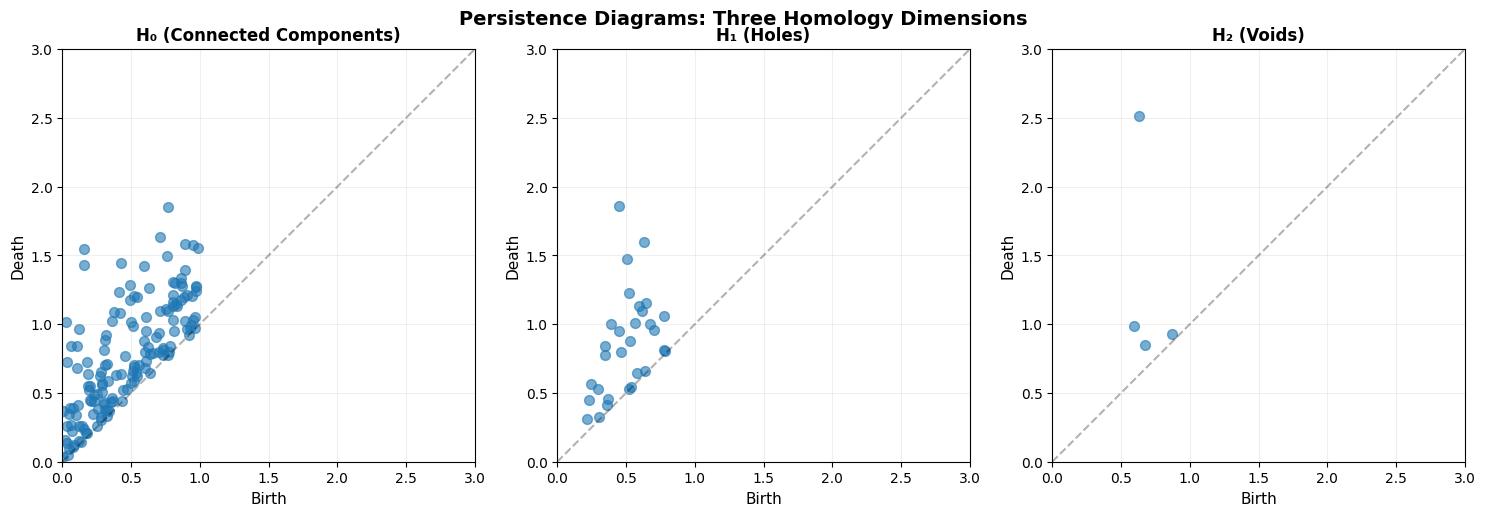

H₀ Persistence: mean=0.307, std=0.275
H₁ Persistence: mean=0.360, std=0.327
H₂ Persistence: mean=1.022, std=1.028


In [10]:
# Example 2: Synthetic persistence diagram
# Real output from DIAG class: CSV file with [dimension, birth, death]

# Create synthetic persistence diagram
np.random.seed(42)

# H0 (connected components) - generally more features
h0_birth = np.random.uniform(0, 1, 150)
h0_death = h0_birth + np.random.exponential(0.3, 150)
h0_points = np.column_stack([h0_birth, h0_death])

# H1 (holes/voids) - fewer features, generally larger persistence
h1_birth = np.random.uniform(0.2, 0.8, 30)
h1_death = h1_birth + np.random.exponential(0.5, 30)
h1_points = np.column_stack([h1_birth, h1_death])

# H2 (cavities) - rare features
h2_birth = np.random.uniform(0.4, 0.9, 5)
h2_death = h2_birth + np.random.exponential(0.8, 5)
h2_points = np.column_stack([h2_birth, h2_death])

# Plot persistence diagrams
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

max_val = 3
for ax, (points, title) in zip(axes, [(h0_points, 'H₀ (Connected Components)'), 
                                        (h1_points, 'H₁ (Holes)'),
                                        (h2_points, 'H₂ (Voids)')]):
    # Plot diagonal (trivial features)
    ax.plot([0, max_val], [0, max_val], 'k--', alpha=0.3, label='Diagonal')
    
    # Plot points
    ax.scatter(points[:, 0], points[:, 1], alpha=0.6, s=50)
    
    # Labels
    ax.set_xlabel('Birth', fontsize=11)
    ax.set_ylabel('Death', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(0, max_val)
    ax.set_ylim(0, max_val)
    ax.set_aspect('equal')
    ax.grid(alpha=0.2)

plt.suptitle('Persistence Diagrams: Three Homology Dimensions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Compute persistence
persistence_h0 = h0_death - h0_birth
print(f"H₀ Persistence: mean={persistence_h0.mean():.3f}, std={persistence_h0.std():.3f}")
print(f"H₁ Persistence: mean={(h1_death-h1_birth).mean():.3f}, std={(h1_death-h1_birth).std():.3f}")
print(f"H₂ Persistence: mean={(h2_death-h2_birth).mean():.3f}, std={(h2_death-h2_birth).std():.3f}")

### Understanding Persistence Images

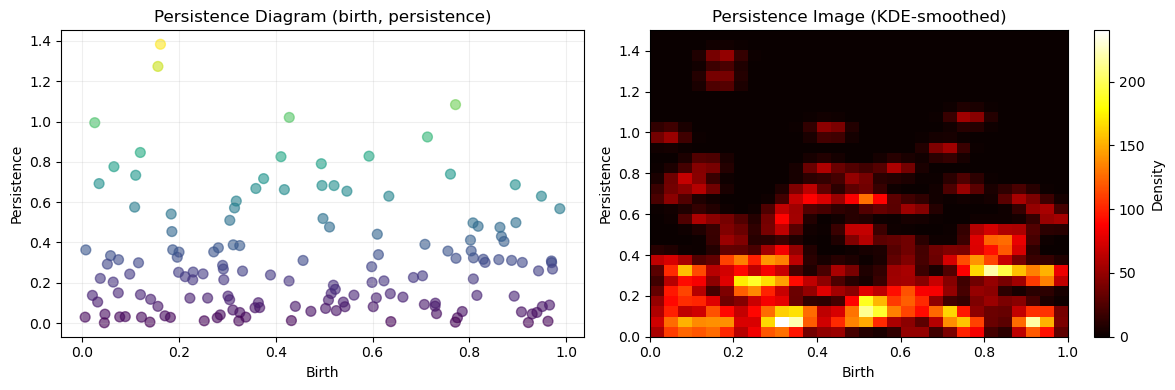

Persistence Image Shape: (30, 30)
Can be flattened to feature vector of size 900 for ML


In [3]:
from scipy.stats import gaussian_kde

# Example 3: Convert persistence diagram to persistence image

# Use H0 points as example
persistence = h0_death - h0_birth
pd_coords = np.column_stack([h0_birth, persistence])  # (birth, persistence) coordinates

# Create grid
grid_res = 30
birth_range = np.linspace(0, 1, grid_res)
pers_range = np.linspace(0, 1.5, grid_res)

# Compute 2D KDE
kde = gaussian_kde(pd_coords.T, bw_method=0.1)

# Evaluate on grid
birth_grid, pers_grid = np.meshgrid(birth_range, pers_range)
positions = np.vstack([birth_grid.ravel(), pers_grid.ravel()])
density = kde(positions).reshape(birth_grid.shape)

# Weight by persistence
pi_image = density * np.sum(persistence)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Original diagram
axes[0].scatter(h0_birth, persistence, c=persistence, cmap='viridis', s=50, alpha=0.6)
axes[0].set_xlabel('Birth')
axes[0].set_ylabel('Persistence')
axes[0].set_title('Persistence Diagram (birth, persistence)')
axes[0].grid(alpha=0.2)

# Persistence image
im = axes[1].imshow(pi_image, extent=[0, 1, 0, 1.5], origin='lower', cmap='hot', aspect='auto')
axes[1].set_xlabel('Birth')
axes[1].set_ylabel('Persistence')
axes[1].set_title('Persistence Image (KDE-smoothed)')
plt.colorbar(im, ax=axes[1], label='Density')

plt.tight_layout()
plt.show()

print(f"Persistence Image Shape: {pi_image.shape}")
print(f"Can be flattened to feature vector of size {pi_image.size} for ML")

### Distance-To-Measure (DTM) Visualization

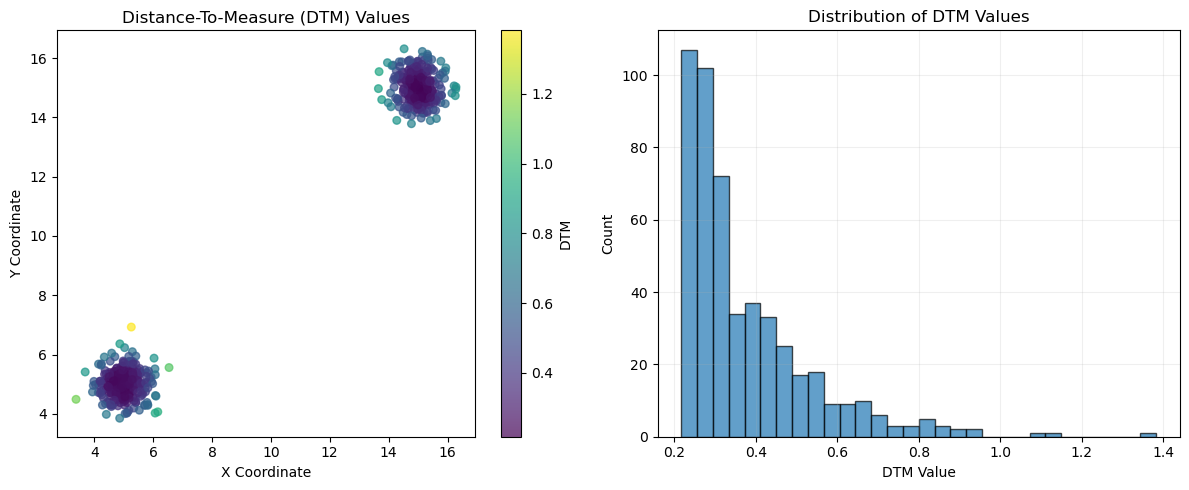

DTM Statistics:
  Min: 0.2168
  Max: 1.3825
  Mean: 0.3741

Interpretation:
  - Dense clusters (low DTM): represent high-density regions
  - Void regions (high DTM): represent sparse regions


In [6]:
from sklearn.neighbors import KDTree

# Example 4: DTM computation and visualization

# Create 2D point cloud (easier to visualize)
np.random.seed(42)
n_points = 500

# Create clusters
cluster1 = np.random.normal([5, 5], scale=0.5, size=(250, 2))
cluster2 = np.random.normal([15, 15], scale=0.5, size=(250, 2))
points = np.vstack([cluster1, cluster2])

# Compute DTM at each point
m = 0.1  # Use 10% of points for k-NN
k = int(np.floor(m * len(points))) + 1

kdt = KDTree(points, leaf_size=30)
distances, indices = kdt.query(points, k)
dtm_values = np.sqrt(np.sum(distances[:, 1:] ** 2, axis=1) / (k - 1))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# DTM values
scatter1 = axes[0].scatter(points[:, 0], points[:, 1], c=dtm_values, cmap='viridis', s=30, alpha=0.7)
axes[0].set_xlabel('X Coordinate')
axes[0].set_ylabel('Y Coordinate')
axes[0].set_title('Distance-To-Measure (DTM) Values')
plt.colorbar(scatter1, ax=axes[0], label='DTM')

# DTM distribution
axes[1].hist(dtm_values, bins=30, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('DTM Value')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of DTM Values')
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

print(f"DTM Statistics:")
print(f"  Min: {dtm_values.min():.4f}")
print(f"  Max: {dtm_values.max():.4f}")
print(f"  Mean: {dtm_values.mean():.4f}")
print(f"\nInterpretation:")
print(f"  - Dense clusters (low DTM): represent high-density regions")
print(f"  - Void regions (high DTM): represent sparse regions")

### Sub-box Partitioning

Box Configuration:
  Main box: 2000 × 2000 × 2000 Mpc/h
  Sub-box size: 1000 × 1000 × 1000 Mpc/h
  Sub-box grid: 2 × 2 × 2
  Total sub-boxes: 8

With 4 processors: ~2 sub-boxes per processor


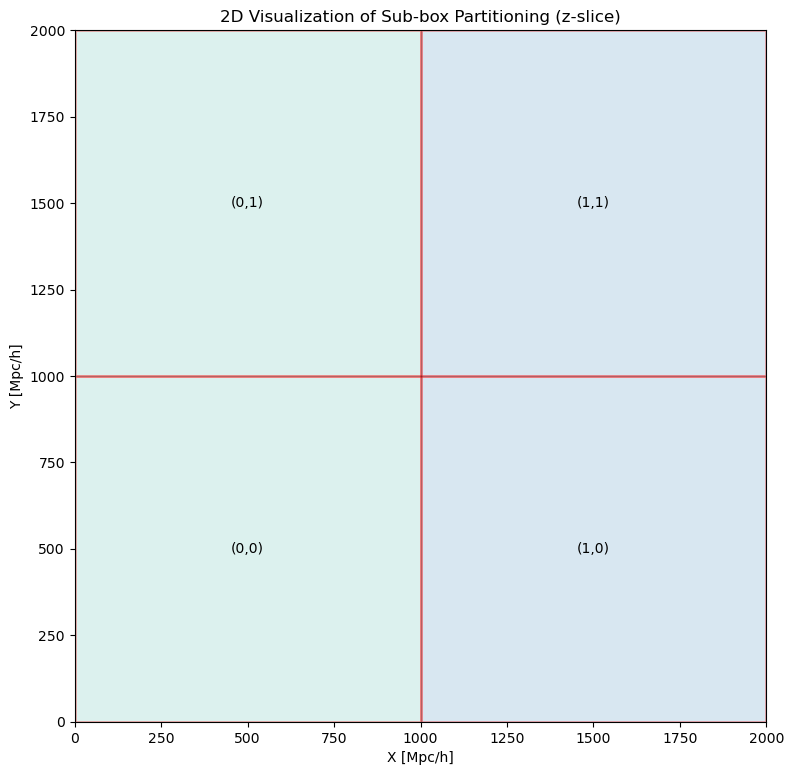

In [7]:
# Example 5: Understanding box partitioning for parallel computation

# Parameters
box_size = 2000  # Mpc/h
sub_box_size = 1000  # Mpc/h

# Calculate grid
nsub = int(box_size / sub_box_size)
print(f"Box Configuration:")
print(f"  Main box: {box_size} × {box_size} × {box_size} Mpc/h")
print(f"  Sub-box size: {sub_box_size} × {sub_box_size} × {sub_box_size} Mpc/h")
print(f"  Sub-box grid: {nsub} × {nsub} × {nsub}")
print(f"  Total sub-boxes: {nsub**3}")
print(f"\nWith {4} processors: ~{nsub**3/4:.0f} sub-boxes per processor")

# Visualize 2D slice
fig, ax = plt.subplots(figsize=(8, 8))

# Draw grid
for i in range(nsub + 1):
    ax.axhline(y=i * sub_box_size, color='k', linewidth=0.5, alpha=0.3)
    ax.axvline(x=i * sub_box_size, color='k', linewidth=0.5, alpha=0.3)

# Color some sub-boxes
colors = plt.cm.Set3(np.linspace(0, 1, 4))
for idx, (i, color) in enumerate(zip(range(0, 2), colors)):
    for j in range(2):
        rect = plt.Rectangle((i * sub_box_size, j * sub_box_size), 
                            sub_box_size, sub_box_size,
                            facecolor=color, alpha=0.3, edgecolor='red', linewidth=2)
        ax.add_patch(rect)
        ax.text(i * sub_box_size + sub_box_size/2, j * sub_box_size + sub_box_size/2,
               f'({i},{j})', ha='center', va='center', fontsize=10)

ax.set_xlim(0, box_size)
ax.set_ylim(0, box_size)
ax.set_aspect('equal')
ax.set_xlabel('X [Mpc/h]')
ax.set_ylabel('Y [Mpc/h]')
ax.set_title(f'2D Visualization of Sub-box Partitioning (z-slice)')
plt.tight_layout()
plt.show()

### Four Filtration Methods Comparison

In [8]:
# Example 6: Conceptual comparison of four filtration methods

methods_info = {
    'Method 0: Alpha Filtration': {
        'desc': 'Pure geometric distance-based',
        'pros': ['Simple', 'Standard', 'Fast'],
        'cons': ['No density information', 'Sensitive to noise'],
        'edge_rule': 'Euclidean distance'
    },
    'Method 1: Sublevel Filtration': {
        'desc': 'Height function-based (cubical complex)',
        'pros': ['Captures field structure', 'Handles non-Euclidean'],
        'cons': ['Discrete (cubical)', 'Resolution-dependent'],
        'edge_rule': 'Field value (height)'
    },
    'Method 2: Alpha-DTM': {
        'desc': 'Alpha complex weighted by density',
        'pros': ['Noise robust', 'Density-aware'],
        'cons': ['Computationally expensive', 'Parameter-dependent'],
        'edge_rule': 'max(DTM_i, DTM_j)'
    },
    'Method 3: Alpha-DTM + Length-DTM': {
        'desc': 'Enhanced density weighting with edge distance',
        'pros': ['Most noise robust', 'Best for LSS'],
        'cons': ['Slowest', 'Complex computation'],
        'edge_rule': 'Mixed DTM-based formula'
    }
}

for method, info in methods_info.items():
    print(f"\n{'='*70}")
    print(f"{method}")
    print(f"{'='*70}")
    print(f"Description: {info['desc']}")
    print(f"Pros: {', '.join(info['pros'])}")
    print(f"Cons: {', '.join(info['cons'])}")
    print(f"Edge Rule: {info['edge_rule']}")


Method 0: Alpha Filtration
Description: Pure geometric distance-based
Pros: Simple, Standard, Fast
Cons: No density information, Sensitive to noise
Edge Rule: Euclidean distance

Method 1: Sublevel Filtration
Description: Height function-based (cubical complex)
Pros: Captures field structure, Handles non-Euclidean
Cons: Discrete (cubical), Resolution-dependent
Edge Rule: Field value (height)

Method 2: Alpha-DTM
Description: Alpha complex weighted by density
Pros: Noise robust, Density-aware
Cons: Computationally expensive, Parameter-dependent
Edge Rule: max(DTM_i, DTM_j)

Method 3: Alpha-DTM + Length-DTM
Description: Enhanced density weighting with edge distance
Pros: Most noise robust, Best for LSS
Cons: Slowest, Complex computation
Edge Rule: Mixed DTM-based formula


### Cosmological Interpretation

**Why persistence homology is valuable for cosmology**:

1. **Primordial non-Gaussianity (PNG)**
   - Traditional power spectrum only captures Gaussian statistics
   - PNG leaves imprints on topological features
   - Persistence homology captures these signatures

2. **Scale-dependent information**
   - Birth scale: When structure forms
   - Death scale: When it merges
   - Different scales → different physics

3. **Complementary to other methods**
   - Power spectrum: 2-point statistics
   - Bispectrum: 3-point statistics  
   - Persistent homology: **Topology** - independent information

4. **Mass selection effects**
   - Mass threshold changes halo population
   - Affects topological features
   - Can constrain halo mass function

### Output Interpretation

- **Persistence diagrams**: Raw topological features (birth, death) by dimension
- **Persistence images**: Machine-learning-ready 2D feature images
- **Betti curves**: 1D summaries of topological evolution
- **Statistics files**: Bounds and outlier information for further analysis

### Workflow: Real Data First, Simulation Fallback

Run this block before the advanced sections.

Execution order:
1. Check whether real local data is available
2. If available, load it
3. If not, create a simulation fallback
4. Run a simple sanity visualization
5. Continue to advanced topology sections

In [1]:
# Step 1: Data gate (real data first, simulation fallback)
from pathlib import Path
import numpy as np
import pandas as pd

REAL_DATA_CANDIDATES = [
    Path('data/real/sdss_real_catalog_xyzm.npy'),
    Path('data/real/real_catalog_xyzm.npy'),
    Path('data/eos/G85L/catalog.npy'),
]


def _load_simple_catalog(path_obj):
    """Load a basic [Mass, X, Y, Z]-compatible array from local file."""
    suffix = path_obj.suffix.lower()

    if suffix == '.npy':
        arr = np.load(path_obj)
    elif suffix in {'.csv', '.txt', '.dat'}:
        try:
            arr = np.loadtxt(path_obj)
        except Exception:
            arr = pd.read_csv(path_obj).to_numpy()
    else:
        raise ValueError(f'Unsupported local format in quick gate: {suffix}')

    arr = np.asarray(arr)
    if arr.ndim == 1:
        arr = arr.reshape(1, -1)

    if arr.shape[1] == 3:
        masses = np.ones((arr.shape[0], 1), dtype=float)
        arr = np.concatenate([masses, arr], axis=1)
    elif arr.shape[1] >= 4:
        arr = arr[:, :4]
    else:
        raise ValueError(f'Catalog must have >=3 columns, got shape {arr.shape}')

    mask = np.isfinite(arr).all(axis=1)
    return arr[mask].astype(float)


def _simulate_catalog(n_points=20000, box_size=1000.0, seed=123):
    rng = np.random.default_rng(seed)
    masses = rng.lognormal(mean=np.log(1e13), sigma=0.6, size=n_points)
    xyz = rng.uniform(0.0, box_size, size=(n_points, 3))
    return np.column_stack([masses, xyz])


active_catalog = None
active_source = None

for candidate in REAL_DATA_CANDIDATES:
    if candidate.exists():
        try:
            active_catalog = _load_simple_catalog(candidate)
            active_source = f'real-local: {candidate}'
            break
        except Exception as exc:
            print(f'Skipping {candidate} ({exc})')

if active_catalog is None:
    active_catalog = _simulate_catalog(n_points=20000, box_size=1000.0, seed=123)
    active_source = 'simulation-fallback'

print(f'Active data source: {active_source}')
print(f'Active catalog shape [Mass, X, Y, Z]: {active_catalog.shape}')
print('First row:', active_catalog[0])

Active data source: simulation-fallback
Active catalog shape [Mass, X, Y, Z]: (20000, 4)
First row: [5.52405550e+12 9.07853035e+02 9.13967988e+02 6.25928542e+02]


Coordinate min: [0.054 0.079 0.131]
Coordinate max: [999.996 999.937 999.96 ]
Mass stats: {'min': 706110903600.3274, 'median': 10011555469067.705, 'max': 89429977913698.2}


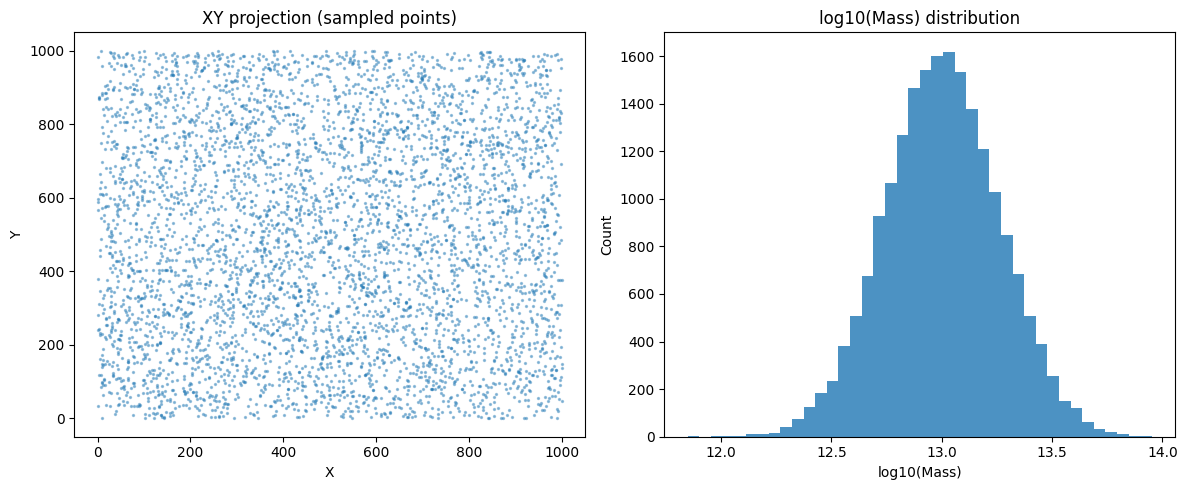

Prepared active_points_2d with shape: (5000, 2)


In [2]:
# Step 2: Simple sanity checks and visualization (start simple)
import matplotlib.pyplot as plt

xyz = active_catalog[:, 1:4]
mass = active_catalog[:, 0]

print('Coordinate min:', xyz.min(axis=0).round(3))
print('Coordinate max:', xyz.max(axis=0).round(3))
print('Mass stats:', {
    'min': float(np.min(mass)),
    'median': float(np.median(mass)),
    'max': float(np.max(mass)),
})

sample_n = min(5000, len(xyz))
idx = np.random.default_rng(7).choice(len(xyz), size=sample_n, replace=False)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(xyz[idx, 0], xyz[idx, 1], s=2, alpha=0.4)
ax[0].set_title('XY projection (sampled points)')
ax[0].set_xlabel('X')
ax[0].set_ylabel('Y')

ax[1].hist(np.log10(np.clip(mass, 1e-12, None)), bins=40, alpha=0.8)
ax[1].set_title('log10(Mass) distribution')
ax[1].set_xlabel('log10(Mass)')
ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# This variable is used by later sections if you want a small working subset.
active_points_2d = xyz[idx, :2]
print(f'Prepared active_points_2d with shape: {active_points_2d.shape}')

### Next Step: Move to Complex Analysis

After running the two quick-start cells above, continue to the advanced sections below.

Recommended progression:
1. Run the article-inspired comparison section (complex topology pipeline)
2. Run EOS-specific loaders/comparisons if EOS files are present
3. Optionally run SDSS download cells only if you explicitly need fresh remote data

## 9. Article-Inspired Replication and Comparison Study

This section adds a lightweight, reproducible proxy of the workflow described in the attached paper **Topological Echoes of Primordial Physics in the Universe at Large Scales**.

What is replicated from the paper:
- Matched-size catalogs for Gaussian and non-Gaussian realizations
- A DTM-based robustness mechanism that delays the contribution of outlier-like points
- Diagram-level summaries used for detection, including topological curves and persistence images
- A template-style detection task: use a strong non-Gaussian template to detect a weaker non-Gaussian signal

What is *not* exactly replicated:
- The EOS dark-matter halo simulations are not included in this repository
- The paper uses a bespoke Delaunay-based $\alpha$DTM filtration on large 3D halo catalogs
- The experiment below therefore uses a 2D synthetic surrogate and a DTM-weighted edge proxy that preserves the logic of the paper while remaining fast enough for a notebook

The comparison requested by the user is included explicitly:
- Article-inspired DTM-weighted filtration proxy
- Standard Vietoris-Rips filtration
- Persistence images vs persistence landscapes vs topological curves

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from ripser import ripser
from scipy.ndimage import gaussian_filter
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import roc_auc_score
from sklearn.neighbors import NearestNeighbors

analysis_rng = np.random.default_rng(12)


def simulate_halo_catalog(
    rng,
    ng_strength=0.0,
    n_points=140,
    grid_size=64,
    smoothing_sigma=3.2,
    bias_strength=1.25,
):
    """Generate a correlated point cloud from a Gaussian or local-NG latent field."""
    gaussian_field = gaussian_filter(rng.normal(size=(grid_size, grid_size)), sigma=smoothing_sigma, mode='wrap')
    gaussian_field = (gaussian_field - gaussian_field.mean()) / gaussian_field.std()

    if ng_strength != 0.0:
        field = gaussian_field + ng_strength * (gaussian_field**2 - np.mean(gaussian_field**2))
        field = gaussian_filter(field, sigma=1.0, mode='wrap')
        field = (field - field.mean()) / field.std()
    else:
        field = gaussian_field

    intensity = np.exp(bias_strength * field)
    intensity = intensity / intensity.sum()

    sampled_cells = rng.choice(grid_size * grid_size, size=n_points, replace=True, p=intensity.ravel())
    y_index, x_index = np.divmod(sampled_cells, grid_size)
    jitter = rng.uniform(0.0, 1.0, size=(n_points, 2))

    points = np.column_stack([x_index, y_index]).astype(float)
    points += jitter
    points /= grid_size
    return points, field, intensity


def compute_dtm(points, k_neighbors=15):
    n_neighbors = min(k_neighbors + 1, len(points))
    model = NearestNeighbors(n_neighbors=n_neighbors)
    model.fit(points)
    distances, _ = model.kneighbors(points)
    return np.sqrt(np.mean(distances[:, 1:] ** 2, axis=1))


def dtm_edge_value(distance_value, vertex_weight_i, vertex_weight_j):
    distance_value = max(float(distance_value), 1e-12)
    plus_term = (vertex_weight_i + vertex_weight_j) ** 2 + distance_value**2
    minus_term = (vertex_weight_i - vertex_weight_j) ** 2 + distance_value**2
    return np.sqrt((plus_term * minus_term) / (4.0 * distance_value**2))


def build_distance_matrices(points, k_neighbors=15):
    euclidean = squareform(pdist(points))
    dtm_values = compute_dtm(points, k_neighbors=k_neighbors)
    weighted = np.zeros_like(euclidean)

    for i in range(len(points)):
        for j in range(i + 1, len(points)):
            edge_birth = dtm_edge_value(euclidean[i, j], dtm_values[i], dtm_values[j])
            weighted[i, j] = weighted[j, i] = 2.0 * edge_birth

    return euclidean, weighted, dtm_values


def finite_h1_diagram(distance_matrix, threshold):
    diagrams = ripser(distance_matrix, maxdim=1, thresh=threshold, distance_matrix=True)['dgms']
    h1 = np.asarray(diagrams[1], dtype=float)
    if h1.size == 0:
        return np.empty((0, 2), dtype=float)
    finite_mask = np.isfinite(h1).all(axis=1)
    h1 = h1[finite_mask]
    return h1[h1[:, 1] > h1[:, 0] + 1e-9]


def topological_curve_vector(diagram, birth_grid, persistence_grid):
    if len(diagram) == 0:
        return np.zeros(birth_grid.size * 3 + persistence_grid.size)

    births = diagram[:, 0]
    deaths = diagram[:, 1]
    persistence = deaths - births

    birth_cdf = np.array([(births <= level).mean() for level in birth_grid])
    death_cdf = np.array([(deaths <= level).mean() for level in birth_grid])
    persistence_cdf = np.array([(persistence <= level).mean() for level in persistence_grid])
    betti_curve = np.array([((births <= level) & (deaths > level)).mean() for level in birth_grid])

    return np.concatenate([birth_cdf, death_cdf, persistence_cdf, betti_curve])


def persistence_image_vector(diagram, birth_grid, persistence_grid, sigma=0.018):
    image = np.zeros((persistence_grid.size, birth_grid.size), dtype=float)
    if len(diagram) == 0:
        return image.ravel()

    births = diagram[:, 0]
    persistence = diagram[:, 1] - diagram[:, 0]
    birth_mesh, persistence_mesh = np.meshgrid(birth_grid, persistence_grid)

    for birth_value, persistence_value in zip(births, persistence):
        image += persistence_value * np.exp(
            -(
                (birth_mesh - birth_value) ** 2
                + (persistence_mesh - persistence_value) ** 2
            )
            / (2.0 * sigma**2)
        )

    image /= max(len(diagram), 1)
    return image.ravel()


def persistence_landscape_vector(diagram, x_grid, n_layers=3):
    if len(diagram) == 0:
        return np.zeros(n_layers * x_grid.size)

    tent_functions = []
    for birth_value, death_value in diagram:
        tent_functions.append(np.maximum(0.0, np.minimum(x_grid - birth_value, death_value - x_grid)))

    if not tent_functions:
        return np.zeros(n_layers * x_grid.size)

    ordered_values = np.sort(np.vstack(tent_functions), axis=0)[::-1]
    output = np.zeros((n_layers, x_grid.size), dtype=float)
    n_available = min(n_layers, ordered_values.shape[0])
    output[:n_available] = ordered_values[:n_available]
    return output.ravel()


def build_feature_bundle(diagram, birth_grid, persistence_grid, x_grid):
    return {
        'curves': topological_curve_vector(diagram, birth_grid, persistence_grid),
        'persistence_image': persistence_image_vector(diagram, birth_grid, persistence_grid),
        'landscape': persistence_landscape_vector(diagram, x_grid),
    }


def template_scores(train_g, train_ng, test_g, test_weak_ng):
    mu_g = np.mean(np.vstack(train_g), axis=0)
    mu_ng = np.mean(np.vstack(train_ng), axis=0)

    def score(vector):
        return np.linalg.norm(vector - mu_g) - np.linalg.norm(vector - mu_ng)

    g_scores = np.array([score(vector) for vector in test_g])
    weak_scores = np.array([score(vector) for vector in test_weak_ng])
    labels = np.concatenate([np.zeros_like(g_scores), np.ones_like(weak_scores)])
    scores = np.concatenate([g_scores, weak_scores])

    threshold_975 = np.quantile(g_scores, 0.975)
    pooled_var = (np.var(g_scores) + np.var(weak_scores)) / 2.0
    effect_size = (weak_scores.mean() - g_scores.mean()) / np.sqrt(max(pooled_var, 1e-12))

    return {
        'auc': roc_auc_score(labels, scores),
        'accuracy': np.mean(np.concatenate([g_scores <= 0.0, weak_scores > 0.0])),
        'weak_detection_rate_97p5': np.mean(weak_scores > threshold_975),
        'mean_g_score': g_scores.mean(),
        'mean_weak_ng_score': weak_scores.mean(),
        'effect_size': effect_size,
    }


birth_grid = np.linspace(0.0, 0.42, 34)
persistence_grid = np.linspace(0.0, 0.28, 30)
landscape_grid = np.linspace(0.0, 0.42, 90)

vr_threshold = 0.42
article_threshold = 0.58
strong_ng = 0.90
weak_ng = 0.30

print('Helper functions ready.')
print(f'VR threshold = {vr_threshold:.2f}, article-proxy threshold = {article_threshold:.2f}')
print(f'Strong NG template = {strong_ng:.2f}, weak NG target = {weak_ng:.2f}')

Helper functions ready.
VR threshold = 0.42, article-proxy threshold = 0.58
Strong NG template = 0.90, weak NG target = 0.30


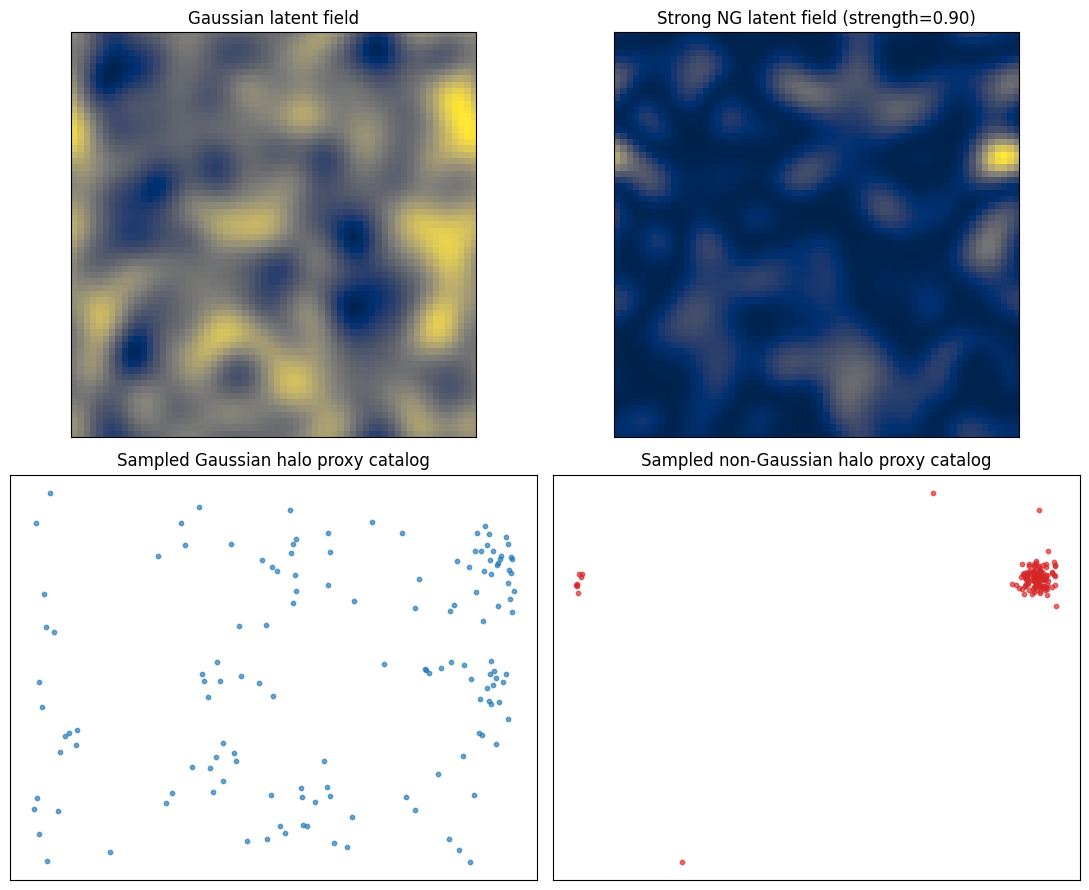

In [4]:
example_gaussian_points, example_gaussian_field, example_gaussian_intensity = simulate_halo_catalog(
    analysis_rng,
    ng_strength=0.0,
)
example_ng_points, example_ng_field, example_ng_intensity = simulate_halo_catalog(
    analysis_rng,
    ng_strength=strong_ng,
)

fig, axes = plt.subplots(2, 2, figsize=(11, 9))

axes[0, 0].imshow(example_gaussian_field, origin='lower', cmap='cividis')
axes[0, 0].set_title('Gaussian latent field')
axes[0, 1].imshow(example_ng_field, origin='lower', cmap='cividis')
axes[0, 1].set_title(f'Strong NG latent field (strength={strong_ng:.2f})')

axes[1, 0].scatter(example_gaussian_points[:, 0], example_gaussian_points[:, 1], s=10, alpha=0.65)
axes[1, 0].set_title('Sampled Gaussian halo proxy catalog')
axes[1, 1].scatter(example_ng_points[:, 0], example_ng_points[:, 1], s=10, alpha=0.65, color='tab:red')
axes[1, 1].set_title('Sampled non-Gaussian halo proxy catalog')

for axis in axes.ravel():
    axis.set_xticks([])
    axis.set_yticks([])

plt.tight_layout()
plt.show()

In [5]:
def collect_features(point_cloud):
    euclidean_distances, article_proxy_distances, dtm_values = build_distance_matrices(point_cloud)

    vr_diagram = finite_h1_diagram(euclidean_distances, threshold=vr_threshold)
    article_diagram = finite_h1_diagram(article_proxy_distances, threshold=article_threshold)

    return {
        'vr': build_feature_bundle(vr_diagram, birth_grid, persistence_grid, landscape_grid),
        'article_proxy': build_feature_bundle(article_diagram, birth_grid, persistence_grid, landscape_grid),
        'diagram_sizes': {
            'vr_h1_features': len(vr_diagram),
            'article_h1_features': len(article_diagram),
            'dtm_mean': float(dtm_values.mean()),
        },
    }


sample_labels = (
    [('train_g', 0.0)] * 12
    + [('train_ng_template', strong_ng)] * 12
    + [('test_g', 0.0)] * 12
    + [('test_weak_ng', weak_ng)] * 12
)

feature_store = {
    'article_proxy_curves': {'train_g': [], 'train_ng_template': [], 'test_g': [], 'test_weak_ng': []},
    'article_proxy_persistence_image': {'train_g': [], 'train_ng_template': [], 'test_g': [], 'test_weak_ng': []},
    'article_proxy_landscape': {'train_g': [], 'train_ng_template': [], 'test_g': [], 'test_weak_ng': []},
    'vr_curves': {'train_g': [], 'train_ng_template': [], 'test_g': [], 'test_weak_ng': []},
    'vr_persistence_image': {'train_g': [], 'train_ng_template': [], 'test_g': [], 'test_weak_ng': []},
    'vr_landscape': {'train_g': [], 'train_ng_template': [], 'test_g': [], 'test_weak_ng': []},
}

diagram_summary_rows = []

for sample_group, ng_strength in sample_labels:
    points, _, _ = simulate_halo_catalog(analysis_rng, ng_strength=ng_strength)
    features = collect_features(points)

    feature_store['article_proxy_curves'][sample_group].append(features['article_proxy']['curves'])
    feature_store['article_proxy_persistence_image'][sample_group].append(features['article_proxy']['persistence_image'])
    feature_store['article_proxy_landscape'][sample_group].append(features['article_proxy']['landscape'])
    feature_store['vr_curves'][sample_group].append(features['vr']['curves'])
    feature_store['vr_persistence_image'][sample_group].append(features['vr']['persistence_image'])
    feature_store['vr_landscape'][sample_group].append(features['vr']['landscape'])

    diagram_summary_rows.append({'sample_group': sample_group, 'ng_strength': ng_strength, **features['diagram_sizes']})

summary_df = pd.DataFrame(diagram_summary_rows)
comparison_rows = []

for method_name, partitions in feature_store.items():
    metrics = template_scores(
        train_g=partitions['train_g'],
        train_ng=partitions['train_ng_template'],
        test_g=partitions['test_g'],
        test_weak_ng=partitions['test_weak_ng'],
    )
    comparison_rows.append({'method': method_name, **metrics})

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    by=['auc', 'weak_detection_rate_97p5', 'effect_size'],
    ascending=False,
)

print('Average H1 feature counts by sample group and filtration proxy:')
display(summary_df.groupby('sample_group')[['vr_h1_features', 'article_h1_features', 'dtm_mean']].mean().round(3))

print('\nTemplate-detection comparison:')
display(comparison_df.round(3))

Average H1 feature counts by sample group and filtration proxy:


,vr_h1_features,article_h1_features,dtm_mean
sample_group,,,
test_g,20.333,7.917,0.124
test_weak_ng,19.417,6.333,0.089
train_g,20.583,6.500,0.118
train_ng_template,20.500,6.333,0.076



Template-detection comparison:


,method,auc,accuracy,weak_detection_rate_97p5,mean_g_score,mean_weak_ng_score,effect_size
3,vr_curves,0.993,0.792,0.917,-1.902,0.399,2.561
4,vr_persistence_image,0.889,0.917,0.833,-0.005,0.004,1.939
5,vr_landscape,0.861,0.833,0.667,-0.034,0.035,1.635
0,article_proxy_curves,0.826,0.750,0.667,-2.379,0.433,1.553
2,article_proxy_landscape,0.792,0.625,0.750,0.005,0.014,0.947
1,article_proxy_persistence_image,0.764,0.625,0.583,0.003,0.007,1.133


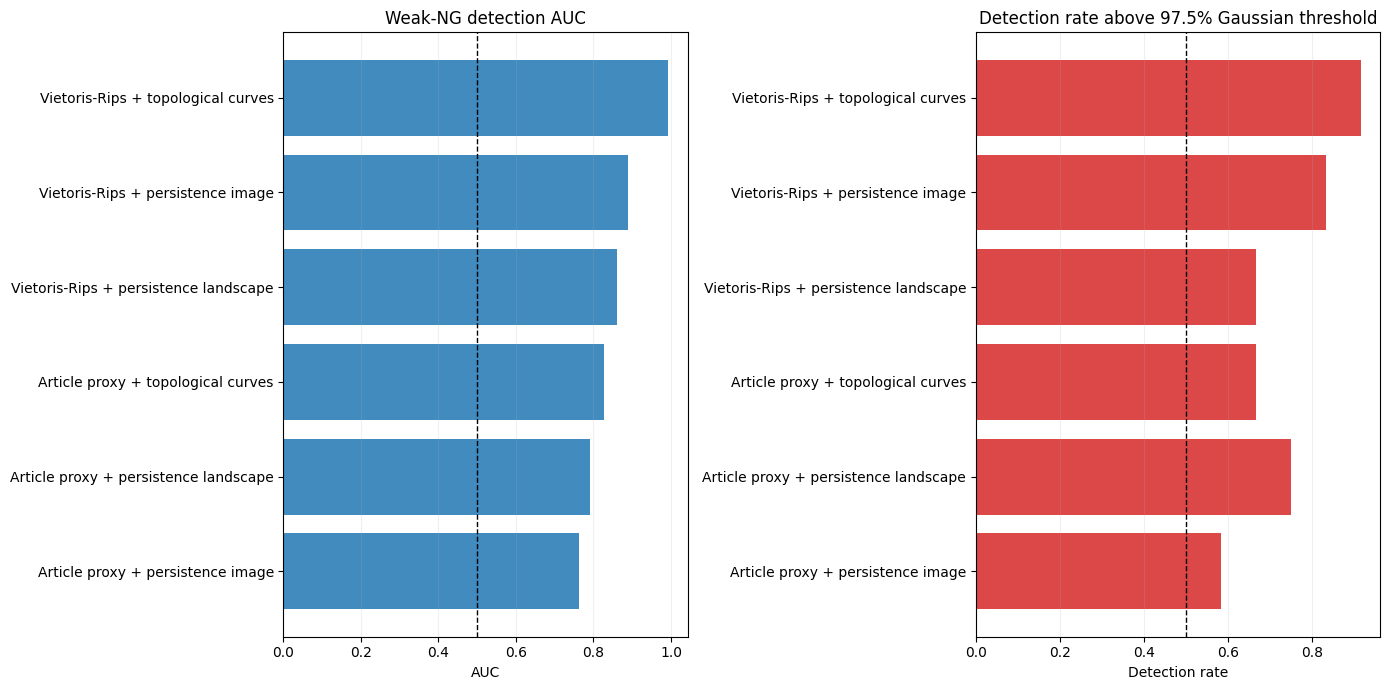

Best proxy in this notebook run:
  Vietoris-Rips + topological curves | AUC=0.993 | detection@97.5%=0.917
Weakest proxy in this notebook run:
  Article proxy + persistence image | AUC=0.764 | detection@97.5%=0.583


In [6]:
method_labels = {
    'article_proxy_curves': 'Article proxy + topological curves',
    'article_proxy_persistence_image': 'Article proxy + persistence image',
    'article_proxy_landscape': 'Article proxy + persistence landscape',
    'vr_curves': 'Vietoris-Rips + topological curves',
    'vr_persistence_image': 'Vietoris-Rips + persistence image',
    'vr_landscape': 'Vietoris-Rips + persistence landscape',
}

plot_df = comparison_df.copy()
plot_df['label'] = plot_df['method'].map(method_labels)
plot_df = plot_df.sort_values('auc', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

axes[0].barh(plot_df['label'], plot_df['auc'], color='#1f77b4', alpha=0.85)
axes[0].set_title('Weak-NG detection AUC')
axes[0].set_xlabel('AUC')
axes[0].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[0].grid(alpha=0.2, axis='x')

axes[1].barh(plot_df['label'], plot_df['weak_detection_rate_97p5'], color='#d62728', alpha=0.85)
axes[1].set_title('Detection rate above 97.5% Gaussian threshold')
axes[1].set_xlabel('Detection rate')
axes[1].axvline(0.5, color='black', linestyle='--', linewidth=1)
axes[1].grid(alpha=0.2, axis='x')

plt.tight_layout()
plt.show()

best_row = comparison_df.iloc[0]
worst_row = comparison_df.iloc[-1]

print('Best proxy in this notebook run:')
print(f"  {method_labels[best_row['method']]} | AUC={best_row['auc']:.3f} | detection@97.5%={best_row['weak_detection_rate_97p5']:.3f}")
print('Weakest proxy in this notebook run:')
print(f"  {method_labels[worst_row['method']]} | AUC={worst_row['auc']:.3f} | detection@97.5%={worst_row['weak_detection_rate_97p5']:.3f}")

In [7]:
compact_results = comparison_df[['method', 'auc', 'accuracy', 'weak_detection_rate_97p5', 'effect_size']].copy()
compact_results['method'] = compact_results['method'].map(method_labels)
compact_results = compact_results.round(3)
compact_results

,method,auc,accuracy,weak_detection_rate_97p5,effect_size
3,Vietoris-Rips + topological curves,0.993,0.792,0.917,2.561
4,Vietoris-Rips + persistence image,0.889,0.917,0.833,1.939
5,Vietoris-Rips + persistence landscape,0.861,0.833,0.667,1.635
0,Article proxy + topological curves,0.826,0.750,0.667,1.553
2,Article proxy + persistence landscape,0.792,0.625,0.750,0.947
1,Article proxy + persistence image,0.764,0.625,0.583,1.133


## 10. Plugging in EOS Halo Catalogs (Real Data)

This section lets you run the same analysis on real EOS halo catalogs once files are available locally.

Expected structure (example):
- data/eos/G85L/
- data/eos/NG10L/
- data/eos/NG250L/

Each catalog should contain halo mass and positions, with columns compatible with one of these patterns:
- [Mass, X, Y, Z]
- [X, Y, Z]

If your files use other names or layouts, adapt the loader mapping in the next cell.

In [8]:
from pathlib import Path

EOS_ROOT = Path('data/eos')
EOS_GROUPS = ['G85L', 'NG10L', 'NG250L']
EXPECTED_EXTENSIONS = {'.csv', '.txt', '.dat', '.h5', '.hdf5', '.npy'}


def discover_eos_files(root, groups):
    root = Path(root)
    discovered = {}
    for group in groups:
        group_dir = root / group
        files = []
        if group_dir.exists():
            for candidate in group_dir.rglob('*'):
                if candidate.is_file() and candidate.suffix.lower() in EXPECTED_EXTENSIONS:
                    files.append(candidate)
        discovered[group] = sorted(files)
    return discovered


def load_eos_catalog(file_path):
    file_path = Path(file_path)
    suffix = file_path.suffix.lower()

    if suffix == '.npy':
        data = np.load(file_path)
    elif suffix in {'.csv', '.txt', '.dat'}:
        try:
            data = np.loadtxt(file_path)
        except Exception:
            frame = pd.read_csv(file_path)
            data = frame.to_numpy()
    elif suffix in {'.h5', '.hdf5'}:
        import h5py

        with h5py.File(file_path, 'r') as h5f:
            candidate_keys = [
                'catalog',
                'halo_catalog',
                'halos',
                'data',
                'x',
            ]
            selected_key = None
            for key in candidate_keys:
                if key in h5f:
                    selected_key = key
                    break
            if selected_key is None:
                selected_key = list(h5f.keys())[0]
            obj = h5f[selected_key]
            data = obj[()]
    else:
        raise ValueError(f'Unsupported EOS file type: {suffix}')

    data = np.asarray(data)
    if data.ndim == 1:
        data = data.reshape(1, -1)

    if data.shape[1] >= 4:
        catalog = data[:, :4]
    elif data.shape[1] == 3:
        masses = np.ones((data.shape[0], 1), dtype=float)
        catalog = np.concatenate([masses, data], axis=1)
    else:
        raise ValueError(f'Catalog must have at least 3 columns, found shape {data.shape}')

    finite_mask = np.isfinite(catalog).all(axis=1)
    catalog = catalog[finite_mask]
    return catalog.astype(float)


def matched_subsample(points_a, points_b, n_target, rng):
    n_use = min(len(points_a), len(points_b), int(n_target))
    idx_a = rng.choice(len(points_a), size=n_use, replace=False)
    idx_b = rng.choice(len(points_b), size=n_use, replace=False)
    return points_a[idx_a], points_b[idx_b]


eos_files = discover_eos_files(EOS_ROOT, EOS_GROUPS)
for group_name, files in eos_files.items():
    print(f'{group_name}: {len(files)} file(s)')
    for path_obj in files[:3]:
        print(f'  - {path_obj}')

if sum(len(v) for v in eos_files.values()) == 0:
    print('\nNo EOS files found yet. Place catalogs under data/eos/<GROUP>/ and rerun this cell.')

G85L: 0 file(s)
NG10L: 0 file(s)
NG250L: 0 file(s)

No EOS files found yet. Place catalogs under data/eos/<GROUP>/ and rerun this cell.


In [9]:
def eos_points_from_catalog(catalog):
    return catalog[:, 1:4]


def run_eos_quick_comparison(g_file, ng_file, n_subsample=8000):
    g_catalog = load_eos_catalog(g_file)
    ng_catalog = load_eos_catalog(ng_file)

    g_points = eos_points_from_catalog(g_catalog)
    ng_points = eos_points_from_catalog(ng_catalog)

    g_points, ng_points = matched_subsample(g_points, ng_points, n_subsample, analysis_rng)

    g_features = collect_features(g_points)
    ng_features = collect_features(ng_points)

    rows = []
    for filtration_key in ['vr', 'article_proxy']:
        for vectorization_key in ['curves', 'persistence_image', 'landscape']:
            g_vec = g_features[filtration_key][vectorization_key]
            ng_vec = ng_features[filtration_key][vectorization_key]
            distance = np.linalg.norm(ng_vec - g_vec)
            rows.append(
                {
                    'filtration': filtration_key,
                    'vectorization': vectorization_key,
                    'feature_distance': float(distance),
                }
            )

    return pd.DataFrame(rows).sort_values('feature_distance', ascending=False)


# Example usage once files are present:
# g_example = eos_files['G85L'][0]
# ng_example = eos_files['NG10L'][0]
# display(run_eos_quick_comparison(g_example, ng_example, n_subsample=8000))